<a href="https://colab.research.google.com/github/Mitali-Kambli20/CSL701-CE13_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Mitali Manohar Kambli

Roll No : CE13

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Upload the dataset file
from google.colab import files

uploaded = files.upload()

# Get the uploaded filename
file_name = list(uploaded.keys())[0]

# Load the CSV file
df = pd.read_csv(file_name)

# Assign appropriate column names
df.columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Display first five records
print("First five records of the dataset:")
display(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Saving diabetes.csv to diabetes.csv
First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Balance:


,Count,Percentage
Non-Diabetic (0),500,65.104167
Diabetic (1),268,34.895833


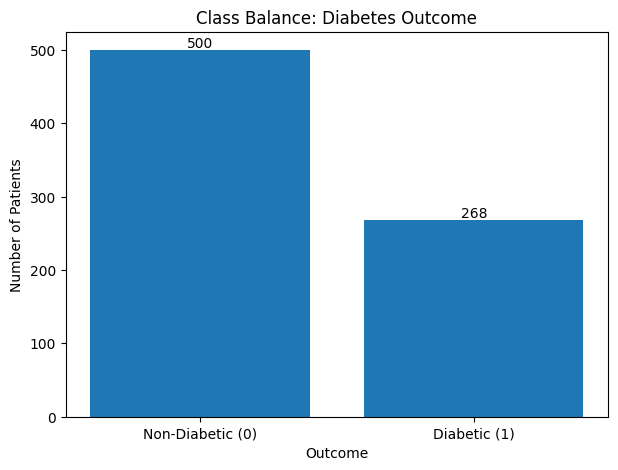

In [6]:
# Calculate absolute count of each class
class_counts = df['Outcome'].value_counts().sort_index()

# Calculate percentage of each class
class_percentages = df['Outcome'].value_counts(normalize=True).sort_index() * 100

# Create a summary table
class_balance = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})

# Rename the classes
class_balance.index = ['Non-Diabetic (0)', 'Diabetic (1)']

# Display class balance
print("Class Balance:")
display(class_balance)

# Plot bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_balance.index,
    class_balance['Count']
)

plt.title('Class Balance: Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Number of Patients')

# Display count on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [7]:
# ============================================================
# TASK 3: PREPROCESSING AND HANDLING MISSING VALUES
# ============================================================

# ------------------------------------------------------------
# STEP 1: Identify features where value 0 is physically
#         impossible or represents a missing measurement
# ------------------------------------------------------------

# In these columns, a value of 0 is considered invalid.
invalid_zero_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("Features where 0 is considered an invalid value:")
print(invalid_zero_features)


# ------------------------------------------------------------
# STEP 2: Count the number of 0 values in each feature
#         BEFORE replacing them with NaN
# ------------------------------------------------------------

print("\nNumber of 0 values before replacement:")

for column in invalid_zero_features:
    zero_count = (df[column] == 0).sum()
    print(column, ":", zero_count)


# ------------------------------------------------------------
# STEP 3: Replace all invalid 0 values with NaN
# ------------------------------------------------------------

# np.nan represents a missing value.
# This allows us to identify and handle the invalid values
# as missing data.

df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)

print("\nInvalid 0 values have been replaced with NaN.")


# ------------------------------------------------------------
# STEP 4: Check how many missing values are present
#         after replacing 0 with NaN
# ------------------------------------------------------------

print("\nMissing values after replacing 0 with NaN:")

print(df.isnull().sum())


# ------------------------------------------------------------
# STEP 5: Handle missing values using MEDIAN IMPUTATION
# ------------------------------------------------------------

# For every feature, calculate its median value and use
# that median to replace the missing values.

for column in invalid_zero_features:

    # Calculate the median of the current column
    median_value = df[column].median()

    # Replace NaN values with the median
    df[column] = df[column].fillna(median_value)

    print(
        f"Missing values in {column} replaced with median = {median_value}"
    )


# ------------------------------------------------------------
# STEP 6: Verify that there are no missing values remaining
# ------------------------------------------------------------

print("\nMissing values after median imputation:")

print(df.isnull().sum())


# ------------------------------------------------------------
# STEP 7: Display the first five rows after preprocessing
# ------------------------------------------------------------

print("\nFirst five records after preprocessing:")

display(df.head())


# ------------------------------------------------------------
# STEP 8: Display the shape of the dataset
#         to confirm that no rows were deleted
# ------------------------------------------------------------

print("\nDataset shape after preprocessing:")

print(df.shape)

Features where 0 is considered an invalid value:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Number of 0 values before replacement:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Invalid 0 values have been replaced with NaN.

Missing values after replacing 0 with NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing values in Glucose replaced with median = 117.0
Missing values in BloodPressure replaced with median = 72.0
Missing values in SkinThickness replaced with median = 29.0
Missing values in Insulin replaced with median = 125.0
Missing values in BMI replaced with median = 32.3

Missing values after median imputation:
Pregnancies                 0
Glucose                     0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



Dataset shape after preprocessing:
(768, 9)


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [8]:
# ============================================================
# TASK 4: STRATIFIED TRAIN-TEST SPLITTING
# ============================================================


# ------------------------------------------------------------
# STEP 1: Separate the FEATURES (X) and TARGET (y)
# ------------------------------------------------------------

# X contains the first 8 columns (predictor variables).
# These features will be used by the model to make predictions.

X = df.iloc[:, :-1]

# y contains the 9th column, which is the target variable.
# Outcome:
# 0 = Non-Diabetic
# 1 = Diabetic

y = df.iloc[:, -1]


# ------------------------------------------------------------
# STEP 2: Display the shape of X and y
# ------------------------------------------------------------

print("Feature matrix (X) shape:", X.shape)
print("Target vector (y) shape:", y.shape)


# ------------------------------------------------------------
# STEP 3: Split the data into 80% TRAINING and 20% TESTING
# ------------------------------------------------------------

# test_size=0.20 means:
# 80% of the data → Training data
# 20% of the data → Testing data
#
# stratify=y ensures that the proportion of
# Outcome = 0 and Outcome = 1 remains similar
# in both training and testing datasets.
#
# random_state=42 makes the split reproducible.
# This means we get the same split every time we run the code.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ------------------------------------------------------------
# STEP 4: Display the size of training and testing datasets
# ------------------------------------------------------------

print("\nTraining data:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting data:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# ------------------------------------------------------------
# STEP 5: Check class distribution in the ORIGINAL dataset
# ------------------------------------------------------------

print("\nOriginal Dataset Class Distribution:")

print(
    y.value_counts(normalize=True).sort_index() * 100
)


# ------------------------------------------------------------
# STEP 6: Check class distribution in the TRAINING dataset
# ------------------------------------------------------------

print("\nTraining Dataset Class Distribution:")

print(
    y_train.value_counts(normalize=True).sort_index() * 100
)


# ------------------------------------------------------------
# STEP 7: Check class distribution in the TESTING dataset
# ------------------------------------------------------------

print("\nTesting Dataset Class Distribution:")

print(
    y_test.value_counts(normalize=True).sort_index() * 100
)

Feature matrix (X) shape: (768, 8)
Target vector (y) shape: (768,)

Training data:
X_train shape: (614, 8)
y_train shape: (614,)

Testing data:
X_test shape: (154, 8)
y_test shape: (154,)

Original Dataset Class Distribution:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Training Dataset Class Distribution:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Testing Dataset Class Distribution:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [9]:
# ============================================================
# TASK 5: CUSTOM BOOTSTRAP SAMPLING FUNCTION
# ============================================================


# ------------------------------------------------------------
# STEP 1: Define the Bootstrap Sampling Function
# ------------------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample from the training data.

    Sampling is performed WITH REPLACEMENT.

    Input:
        X = Feature matrix
        y = Target vector

    Output:
        X_bootstrap = Resampled feature matrix
        y_bootstrap = Resampled target vector
        sample_indices = Indices selected during bootstrapping
    """

    # Get the number of training samples
    N = len(X)

    # Randomly select N indices from 0 to N-1
    # replace=True means sampling is WITH REPLACEMENT.
    #
    # Therefore, the same index can be selected
    # more than once.
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Select the corresponding rows from X
    X_bootstrap = X.iloc[sample_indices]

    # Select the corresponding target values from y
    y_bootstrap = y.iloc[sample_indices]

    # Return the bootstrap sample and selected indices
    return X_bootstrap, y_bootstrap, sample_indices


# ------------------------------------------------------------
# STEP 2: Generate ONE Bootstrap Sample
# ------------------------------------------------------------

X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# ------------------------------------------------------------
# STEP 3: Display the size of the Bootstrap Sample
# ------------------------------------------------------------

print("Original Training Dataset:")
print("Number of samples:", len(X_train))

print("\nBootstrap Dataset:")
print("Number of samples:", len(X_bootstrap))

print("Number of target values:", len(y_bootstrap))


# ------------------------------------------------------------
# STEP 4: Display the first 20 selected indices
# ------------------------------------------------------------

print("\nFirst 20 randomly selected indices:")
print(sample_indices[:20])


# ------------------------------------------------------------
# STEP 5: Check whether duplicate indices exist
# ------------------------------------------------------------

# np.unique() returns only unique indices.
# If the number of unique indices is smaller than N,
# it means some indices were selected more than once.

unique_indices = np.unique(sample_indices)

print("\nNumber of unique indices selected:",
      len(unique_indices))

print("Number of total selections:",
      len(sample_indices))


# Check whether duplicates exist
if len(unique_indices) < len(sample_indices):
    print("\n✓ Duplicate rows are present.")
    print("This confirms sampling was performed WITH replacement.")
else:
    print("\n✗ No duplicate rows found.")


# ------------------------------------------------------------
# STEP 6: Find the duplicated indices
# ------------------------------------------------------------

# Count how many times each index was selected
index_counts = pd.Series(sample_indices).value_counts()

# Keep only indices that appeared more than once
duplicated_indices = index_counts[index_counts > 1]

print("\nDuplicated original row indices:")
print(duplicated_indices)


# ------------------------------------------------------------
# STEP 7: Find the Out-of-Bag (OOB) indices
# ------------------------------------------------------------

# All original training indices
original_indices = np.arange(len(X_train))

# Find indices that were NOT selected in the bootstrap sample
oob_indices = np.setdiff1d(
    original_indices,
    unique_indices
)

print("\nOut-of-Bag (OOB) indices:")
print(oob_indices)

print("\nNumber of OOB samples:",
      len(oob_indices))


# ------------------------------------------------------------
# STEP 8: Create the OOB datasets
# ------------------------------------------------------------

# Select the OOB rows from the original training data
X_oob = X_train.iloc[oob_indices]
y_oob = y_train.iloc[oob_indices]

print("\nOOB Feature Matrix Shape:")
print(X_oob.shape)

print("\nOOB Target Vector Shape:")
print(y_oob.shape)


# ------------------------------------------------------------
# STEP 9: Verify Bootstrap Sample Size
# ------------------------------------------------------------

print("\n========== VERIFICATION ==========")

print("Original Training Samples :", len(X_train))
print("Bootstrap Samples         :", len(X_bootstrap))
print("Bootstrap Target Samples  :", len(y_bootstrap))
print("Unique Selected Samples   :", len(unique_indices))
print("OOB Samples               :", len(oob_indices))


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

if len(X_bootstrap) == len(X_train):
    print("\n✓ Bootstrap sample has the same size as training data.")

if len(duplicated_indices) > 0:
    print("✓ Duplicate indices were found.")

if len(oob_indices) > 0:
    print("✓ OOB samples were found.")

print("\nBootstrap sampling is working correctly!")

Original Training Dataset:
Number of samples: 614

Bootstrap Dataset:
Number of samples: 614
Number of target values: 614

First 20 randomly selected indices:
[370 195 389 351 365 210 295 276 185 583 442 189 140 436 529 272  20 508
 447 373]

Number of unique indices selected: 388
Number of total selections: 614

✓ Duplicate rows are present.
This confirms sampling was performed WITH replacement.

Duplicated original row indices:
283    5
229    5
306    4
613    4
433    4
      ..
286    2
276    2
583    2
442    2
195    2
Name: count, Length: 160, dtype: int64

Out-of-Bag (OOB) indices:
[  0   1   2   5   6   8  11  12  14  24  25  26  27  33  35  36  38  40
  41  47  55  56  58  60  61  62  66  68  70  73  78  79  83  91  92  94
  95 104 106 107 110 118 121 124 125 126 131 132 136 138 139 143 146 148
 151 153 154 155 163 164 168 174 177 178 181 187 191 194 202 204 205 208
 209 212 213 215 217 218 219 222 223 227 230 231 232 234 235 236 237 238
 247 250 251 253 255 256 262 263 267

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [10]:
# ============================================================
# TASK 6: GROWING THE ENSEMBLE OF BASE CLASSIFIERS
# ============================================================


# ------------------------------------------------------------
# STEP 1: Set the number of bootstrap iterations
# ------------------------------------------------------------

# B represents the total number of Decision Trees
# that we want to create in our Bagging ensemble.

B = 50

print("Number of Decision Trees to be created:", B)


# ------------------------------------------------------------
# STEP 2: Create an empty list to store all trained models
# ------------------------------------------------------------

# Each trained Decision Tree will be stored in this list.

ensemble_models = []

print("\nEmpty ensemble list created.")


# ------------------------------------------------------------
# STEP 3: Train B Decision Trees
# ------------------------------------------------------------

# Repeat the following process 50 times.

for b in range(B):

    # --------------------------------------------------------
    # STEP 3.1: Generate a bootstrap sample
    # --------------------------------------------------------

    # Use the bootstrap function created in Task 5.
    #
    # Each iteration gets a different random sample
    # of the training data.
    #
    # Sampling is performed WITH replacement.

    X_bootstrap, y_bootstrap, sample_indices = \
        get_bootstrap_sample(X_train, y_train)


    # --------------------------------------------------------
    # STEP 3.2: Create a Decision Tree classifier
    # --------------------------------------------------------

    # max_depth=None means the tree is allowed to grow
    # until the stopping conditions are reached.
    #
    # These fully grown trees can have high variance,
    # which makes them suitable base learners for Bagging.

    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )


    # --------------------------------------------------------
    # STEP 3.3: Train the Decision Tree
    # --------------------------------------------------------

    # Fit the Decision Tree using the bootstrap sample.

    model.fit(
        X_bootstrap,
        y_bootstrap
    )


    # --------------------------------------------------------
    # STEP 3.4: Add the trained model to the ensemble
    # --------------------------------------------------------

    ensemble_models.append(model)


    # Display progress
    print(f"Decision Tree {b + 1}/{B} trained successfully.")


# ------------------------------------------------------------
# STEP 4: Verify the number of trained models
# ------------------------------------------------------------

print("\n========================================")
print("ENSEMBLE TRAINING COMPLETED")
print("========================================")

print("Number of Decision Trees in ensemble:",
      len(ensemble_models))

print("Expected number of Decision Trees:", B)


# ------------------------------------------------------------
# STEP 5: Verify that all 50 models are Decision Trees
# ------------------------------------------------------------

print("\nChecking the first few models:")

for i, model in enumerate(ensemble_models[:5]):
    print(
        f"Model {i + 1}:",
        type(model).__name__,
        "| Max Depth:",
        model.max_depth
    )


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

if len(ensemble_models) == B:
    print("\n✓ Successfully created 50 Decision Trees.")
    print("✓ Each tree was trained on a bootstrap sample.")
    print("✓ All trees use max_depth=None.")
    print("✓ The Bagging ensemble is ready for prediction.")
else:
    print("\n✗ The number of trained models is incorrect.")

Number of Decision Trees to be created: 50

Empty ensemble list created.
Decision Tree 1/50 trained successfully.
Decision Tree 2/50 trained successfully.
Decision Tree 3/50 trained successfully.
Decision Tree 4/50 trained successfully.
Decision Tree 5/50 trained successfully.
Decision Tree 6/50 trained successfully.
Decision Tree 7/50 trained successfully.
Decision Tree 8/50 trained successfully.
Decision Tree 9/50 trained successfully.
Decision Tree 10/50 trained successfully.
Decision Tree 11/50 trained successfully.
Decision Tree 12/50 trained successfully.
Decision Tree 13/50 trained successfully.
Decision Tree 14/50 trained successfully.
Decision Tree 15/50 trained successfully.
Decision Tree 16/50 trained successfully.
Decision Tree 17/50 trained successfully.
Decision Tree 18/50 trained successfully.
Decision Tree 19/50 trained successfully.
Decision Tree 20/50 trained successfully.
Decision Tree 21/50 trained successfully.
Decision Tree 22/50 trained successfully.
Decision Tre

#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [11]:
# ============================================================
# TASK 7: IMPLEMENTING MAJORITY VOTING FROM SCRATCH
# ============================================================


# ------------------------------------------------------------
# STEP 1: Create the custom prediction function
# ------------------------------------------------------------

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting.

    Parameters:
        ensemble : list of trained Decision Tree models
        X_test   : testing feature matrix

    Returns:
        final_predictions : majority-voted predictions
                            for all test samples
    """

    # --------------------------------------------------------
    # STEP 1.1: Collect predictions from all models
    # --------------------------------------------------------

    # This list will store predictions made by every tree.
    all_predictions = []

    for model in ensemble:

        # Each model predicts all samples in X_test
        predictions = model.predict(X_test)

        # Store the predictions
        all_predictions.append(predictions)


    # --------------------------------------------------------
    # STEP 1.2: Convert predictions into a NumPy array
    # --------------------------------------------------------

    # Shape will be:
    # (number of models, number of test samples)
    #
    # For example:
    # (50, 154)

    all_predictions = np.array(all_predictions)


    # --------------------------------------------------------
    # STEP 1.3: Apply majority voting
    # --------------------------------------------------------

    final_predictions = []

    # Loop through every test sample
    for sample_index in range(all_predictions.shape[1]):

        # Get predictions from all 50 trees
        # for the current test sample

        sample_votes = all_predictions[:, sample_index]


        # ----------------------------------------------------
        # Count the votes for class 0
        # ----------------------------------------------------

        votes_for_0 = np.sum(sample_votes == 0)


        # ----------------------------------------------------
        # Count the votes for class 1
        # ----------------------------------------------------

        votes_for_1 = np.sum(sample_votes == 1)


        # ----------------------------------------------------
        # Select the class with the highest number of votes
        # ----------------------------------------------------

        if votes_for_1 > votes_for_0:
            final_class = 1
        else:
            final_class = 0


        # Store the final prediction
        final_predictions.append(final_class)


    # --------------------------------------------------------
    # STEP 1.4: Convert final predictions to NumPy array
    # --------------------------------------------------------

    final_predictions = np.array(final_predictions)


    # Return the majority-voted predictions
    return final_predictions


# ------------------------------------------------------------
# STEP 2: Generate predictions using the Bagging ensemble
# ------------------------------------------------------------

y_bagging_pred = custom_bagging_predict(
    ensemble_models,
    X_test
)


# ------------------------------------------------------------
# STEP 3: Display the first few final predictions
# ------------------------------------------------------------

print("First 20 Bagging Predictions:")

print(y_bagging_pred[:20])


# ------------------------------------------------------------
# STEP 4: Display the actual values for comparison
# ------------------------------------------------------------

print("\nFirst 20 Actual Outcomes:")

print(y_test.iloc[:20].values)


# ------------------------------------------------------------
# STEP 5: Verify the number of predictions
# ------------------------------------------------------------

print("\nNumber of test samples:",
      len(X_test))

print("Number of Bagging predictions:",
      len(y_bagging_pred))


# ------------------------------------------------------------
# STEP 6: Verify that predictions contain only 0 and 1
# ------------------------------------------------------------

unique_predictions = np.unique(y_bagging_pred)

print("\nUnique predicted classes:")
print(unique_predictions)


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

if len(y_bagging_pred) == len(X_test):
    print("\n✓ Prediction generated for every test sample.")

if set(unique_predictions).issubset({0, 1}):
    print("✓ All predictions are either 0 or 1.")

print("✓ Majority voting implemented successfully.")

First 20 Bagging Predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]

First 20 Actual Outcomes:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]

Number of test samples: 154
Number of Bagging predictions: 154

Unique predicted classes:
[0 1]

✓ Prediction generated for every test sample.
✓ All predictions are either 0 or 1.
✓ Majority voting implemented successfully.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [14]:
# Import F1-Score
from sklearn.metrics import f1_score

In [15]:
# ============================================================
# STEP 5: CALCULATE PERFORMANCE METRICS
# ============================================================

# Single Decision Tree Metrics
single_accuracy = accuracy_score(y_test, y_single_pred)
single_precision = precision_score(y_test, y_single_pred, zero_division=0)
single_recall = recall_score(y_test, y_single_pred, zero_division=0)
single_f1 = f1_score(y_test, y_single_pred, zero_division=0)

# Bagging Metrics
bagging_accuracy = accuracy_score(y_test, y_bagging_pred)
bagging_precision = precision_score(y_test, y_bagging_pred, zero_division=0)
bagging_recall = recall_score(y_test, y_bagging_pred, zero_division=0)
bagging_f1 = f1_score(y_test, y_bagging_pred, zero_division=0)


# ============================================================
# STEP 6: PRINT PERFORMANCE METRICS
# ============================================================

print("\n========================================")
print("PERFORMANCE COMPARISON")
print("========================================")

print("\nSingle Decision Tree:")
print("Accuracy  :", round(single_accuracy, 4))
print("Precision :", round(single_precision, 4))
print("Recall    :", round(single_recall, 4))
print("F1-Score  :", round(single_f1, 4))

print("\nBagging Classifier:")
print("Accuracy  :", round(bagging_accuracy, 4))
print("Precision :", round(bagging_precision, 4))
print("Recall    :", round(bagging_recall, 4))
print("F1-Score  :", round(bagging_f1, 4))


# ============================================================
# STEP 7: CREATE COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    'Model': [
        'Single Decision Tree',
        'Custom Bagging'
    ],
    'Accuracy': [
        single_accuracy,
        bagging_accuracy
    ],
    'Precision': [
        single_precision,
        bagging_precision
    ],
    'Recall': [
        single_recall,
        bagging_recall
    ],
    'F1-Score': [
        single_f1,
        bagging_f1
    ]
})

print("\n========================================")
print("MODEL COMPARISON TABLE")
print("========================================")

display(comparison.round(4))


PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy  : 0.6818
Precision : 0.5532
Recall    : 0.4815
F1-Score  : 0.5149

Bagging Classifier:
Accuracy  : 0.7468
Precision : 0.6596
Recall    : 0.5741
F1-Score  : 0.6139

MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score
0,Single Decision Tree,0.6818,0.5532,0.4815,0.5149
1,Custom Bagging,0.7468,0.6596,0.5741,0.6139


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Single Decision Tree probabilities calculated.
Probability predictions from all 50 trees collected.
Probability array shape: (50, 154)

Bagging probabilities calculated by averaging
the probability estimates of all 50 trees.

First 10 probability predictions:

Single Decision Tree:
[1. 0. 0. 1. 1. 0. 0. 1. 0. 1.]

Bagging:
[0.84 0.16 0.04 0.36 0.   0.3  0.32 0.88 0.02 0.92]

ROC-AUC RESULTS
Single Decision Tree AUC: 0.6357
Custom Bagging AUC: 0.8056

AUC Improvement: 0.1698


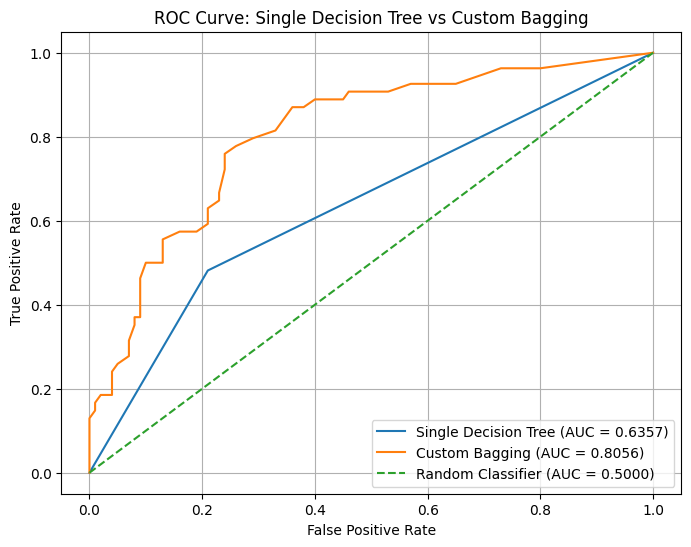

In [16]:
# ============================================================
# TASK 9: ROC-AUC ANALYSIS AND CURVE VISUALIZATION
# ============================================================


# ------------------------------------------------------------
# STEP 1: Calculate probabilities from the SINGLE Decision Tree
# ------------------------------------------------------------

# predict_proba() returns the probability of each class.
#
# Column 0 → Probability of Outcome = 0
# Column 1 → Probability of Outcome = 1
#
# We need the probability of the positive class (Outcome = 1).

single_probabilities = single_tree.predict_proba(X_test)[:, 1]

print("Single Decision Tree probabilities calculated.")


# ------------------------------------------------------------
# STEP 2: Calculate probabilities from ALL 50 Bagging trees
# ------------------------------------------------------------

# Create an empty list to store the probability predictions
# from every Decision Tree.

all_tree_probabilities = []


# Loop through all 50 Decision Trees
for model in ensemble_models:

    # Get probability of Outcome = 1
    probabilities = model.predict_proba(X_test)[:, 1]

    # Store the probabilities
    all_tree_probabilities.append(probabilities)


# Convert the list into a NumPy array
#
# Shape will be:
# (50, number_of_test_samples)

all_tree_probabilities = np.array(all_tree_probabilities)

print("Probability predictions from all 50 trees collected.")

print("Probability array shape:",
      all_tree_probabilities.shape)


# ------------------------------------------------------------
# STEP 3: Average probabilities across all 50 trees
# ------------------------------------------------------------

# For every test sample, calculate the average probability
# predicted by all 50 Decision Trees.

bagging_probabilities = np.mean(
    all_tree_probabilities,
    axis=0
)

print("\nBagging probabilities calculated by averaging")
print("the probability estimates of all 50 trees.")


# ------------------------------------------------------------
# STEP 4: Display some predicted probabilities
# ------------------------------------------------------------

print("\nFirst 10 probability predictions:")

print("\nSingle Decision Tree:")
print(single_probabilities[:10])

print("\nBagging:")
print(bagging_probabilities[:10])


# ============================================================
# STEP 5: Calculate ROC Curve
# ============================================================


# ROC curve for the Single Decision Tree
#
# fpr = False Positive Rate
# tpr = True Positive Rate
# thresholds = different classification thresholds

single_fpr, single_tpr, single_thresholds = roc_curve(
    y_test,
    single_probabilities
)


# ROC curve for the Bagging classifier

bagging_fpr, bagging_tpr, bagging_thresholds = roc_curve(
    y_test,
    bagging_probabilities
)


# ============================================================
# STEP 6: Calculate AUC
# ============================================================

# AUC measures the area under the ROC curve.
#
# A higher AUC generally indicates better ability to
# distinguish between Outcome = 0 and Outcome = 1.

single_auc = roc_auc_score(
    y_test,
    single_probabilities
)

bagging_auc = roc_auc_score(
    y_test,
    bagging_probabilities
)


# ============================================================
# STEP 7: Print AUC Results
# ============================================================

print("\n========================================")
print("ROC-AUC RESULTS")
print("========================================")

print("Single Decision Tree AUC:",
      round(single_auc, 4))

print("Custom Bagging AUC:",
      round(bagging_auc, 4))


# Calculate the difference in AUC

auc_difference = bagging_auc - single_auc

print("\nAUC Improvement:",
      round(auc_difference, 4))


# ============================================================
# STEP 8: Plot ROC Curves
# ============================================================

plt.figure(figsize=(8, 6))


# Plot ROC curve for Single Decision Tree

plt.plot(
    single_fpr,
    single_tpr,
    label=f'Single Decision Tree (AUC = {single_auc:.4f})'
)


# Plot ROC curve for Bagging

plt.plot(
    bagging_fpr,
    bagging_tpr,
    label=f'Custom Bagging (AUC = {bagging_auc:.4f})'
)


# Plot the random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier (AUC = 0.5000)'
)


# Add graph labels

plt.title('ROC Curve: Single Decision Tree vs Custom Bagging')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid(True)

plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [17]:
# ============================================================
# TASK 10: VALIDATION AGAINST SCIKIT-LEARN BAGGINGCLASSIFIER
# ============================================================


# ------------------------------------------------------------
# STEP 1: Import BaggingClassifier
# ------------------------------------------------------------

from sklearn.ensemble import BaggingClassifier


# ------------------------------------------------------------
# STEP 2: Create the base Decision Tree
# ------------------------------------------------------------

# max_depth=None means the Decision Tree is fully grown.
#
# This is the same type of base classifier used in our
# custom Bagging implementation.

base_tree = DecisionTreeClassifier(
    max_depth=None
)

print("✓ Base Decision Tree created.")


# ------------------------------------------------------------
# STEP 3: Create Scikit-Learn's BaggingClassifier
# ------------------------------------------------------------

# n_estimators=50 means 50 Decision Trees will be trained.
#
# bootstrap=True means bootstrap samples are created
# using sampling WITH replacement.

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

print("✓ Scikit-Learn BaggingClassifier created.")
print("Number of estimators:", 50)


# ------------------------------------------------------------
# STEP 4: Train Scikit-Learn BaggingClassifier
# ------------------------------------------------------------

# Train the built-in Bagging classifier using the
# original training data.

sklearn_bagging.fit(
    X_train,
    y_train
)

print("✓ Scikit-Learn BaggingClassifier trained successfully.")


# ------------------------------------------------------------
# STEP 5: Make predictions using Scikit-Learn Bagging
# ------------------------------------------------------------

sklearn_bagging_pred = sklearn_bagging.predict(
    X_test
)

print("✓ Predictions generated.")


# ============================================================
# STEP 6: Calculate Scikit-Learn Bagging Accuracy
# ============================================================

sklearn_accuracy = accuracy_score(
    y_test,
    sklearn_bagging_pred
)

print("\n========================================")
print("SCIKIT-LEARN BAGGING RESULTS")
print("========================================")

print("Accuracy:",
      round(sklearn_accuracy, 4))


# ============================================================
# STEP 7: Create Confusion Matrix
# ============================================================

sklearn_cm = confusion_matrix(
    y_test,
    sklearn_bagging_pred
)

print("\nConfusion Matrix:")
print(sklearn_cm)


# ============================================================
# STEP 8: Compare Custom Bagging with Scikit-Learn Bagging
# ============================================================

# Calculate accuracy of our custom Bagging implementation.
# y_bagging_pred was generated in Task 7.

custom_accuracy = accuracy_score(
    y_test,
    y_bagging_pred
)

print("\n========================================")
print("CUSTOM VS SCIKIT-LEARN BAGGING")
print("========================================")

print("\nCustom Bagging Accuracy:",
      round(custom_accuracy, 4))

print("Scikit-Learn Bagging Accuracy:",
      round(sklearn_accuracy, 4))


# ------------------------------------------------------------
# Compare the accuracy difference
# ------------------------------------------------------------

accuracy_difference = abs(
    custom_accuracy - sklearn_accuracy
)

print("\nAccuracy Difference:",
      round(accuracy_difference, 4))


# ============================================================
# STEP 9: Display Both Confusion Matrices
# ============================================================

print("\n========================================")
print("CONFUSION MATRIX COMPARISON")
print("========================================")

print("\nCustom Bagging:")
print(cm_bagging)

print("\nScikit-Learn Bagging:")
print(sklearn_cm)


# ============================================================
# STEP 10: Check whether predictions are identical
# ============================================================

predictions_same = np.array_equal(
    y_bagging_pred,
    sklearn_bagging_pred
)

print("\nAre all predictions identical?",
      predictions_same)


# ============================================================
# STEP 11: Final Validation Message
# ============================================================

print("\n========================================")
print("VALIDATION SUMMARY")
print("========================================")

if accuracy_difference < 0.05:
    print("✓ Custom and Scikit-Learn Bagging have similar accuracy.")
    print("✓ Custom bootstrap and majority voting logic appears")
    print("  to be working correctly.")
else:
    print("The accuracies differ noticeably.")
    print("This can occur because the bootstrap samples and")
    print("random tree construction are not necessarily identical.")

print("\nCustom Bagging Accuracy:",
      round(custom_accuracy, 4))

print("Scikit-Learn Bagging Accuracy:",
      round(sklearn_accuracy, 4))

✓ Base Decision Tree created.
✓ Scikit-Learn BaggingClassifier created.
Number of estimators: 50
✓ Scikit-Learn BaggingClassifier trained successfully.
✓ Predictions generated.

SCIKIT-LEARN BAGGING RESULTS
Accuracy: 0.7338

Confusion Matrix:
[[85 15]
 [26 28]]

CUSTOM VS SCIKIT-LEARN BAGGING

Custom Bagging Accuracy: 0.7468
Scikit-Learn Bagging Accuracy: 0.7338

Accuracy Difference: 0.013

CONFUSION MATRIX COMPARISON

Custom Bagging:
[[84 16]
 [23 31]]

Scikit-Learn Bagging:
[[85 15]
 [26 28]]

Are all predictions identical? False

VALIDATION SUMMARY
✓ Custom and Scikit-Learn Bagging have similar accuracy.
✓ Custom bootstrap and majority voting logic appears
  to be working correctly.

Custom Bagging Accuracy: 0.7468
Scikit-Learn Bagging Accuracy: 0.7338


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?